# Loan Default Risk — Modelling and Evaluation

This notebook covers the full modelling pipeline for the SuperLender loan default prediction task. It builds on the findings from `01_eda.ipynb` and works through:

1. Data loading, merging, and feature engineering
2. Train/validation split
3. Baseline model — Logistic Regression
4. Handling class imbalance — class weights and SMOTE
5. Model comparison — Logistic Regression, Random Forest, XGBoost
6. Hyperparameter tuning — RandomizedSearchCV
7. Threshold optimisation
8. Final model evaluation
9. SHAP explainability
10. Generating the Zindi submission file

---

## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
import warnings
warnings.filterwarnings("ignore")

sys.path.append(os.path.abspath(".."))

from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

from src.loader import load_and_merge
from src.features import engineer_model_features
from src.model import get_models, get_param_grids, tune_model, save_model, predict_proba
from src.evaluate import evaluate_model, find_optimal_threshold, plot_confusion_matrix, plot_roc_curves, plot_shap_summary

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)
sns.set_theme(style="whitegrid", palette="muted")

%matplotlib inline

## 1. Load, Merge, and Engineer Features

In [2]:
# Load and merge all three training tables
train_df = load_and_merge(split="train")
print(f"Merged training data shape: {train_df.shape}")
train_df.head()

Merged training data shape: (4376, 30)


,customerid,systemloanid,loannumber,approveddate,creationdate,loanamount,totaldue,termdays,referredby,good_bad_flag,birthdate,bank_account_type,longitude_gps,latitude_gps,bank_name_clients,bank_branch_clients,employment_status_clients,level_of_education_clients,prev_loan_count,prev_avg_loanamount,prev_max_loanamount,prev_avg_totaldue,prev_avg_termdays,prev_avg_days_late,prev_max_days_late,prev_late_payment_rate,prev_total_late_payments,prev_avg_interest_ratio,prev_avg_loan_duration,prev_was_referred
0,8a2a81a74ce8c05d014cfb32a0da1049,301994762,12,2017-07-25 08:22:56.000000,2017-07-25 07:22:47.000000,30000.0000,34500.0000,30,NaN,Good,1972-01-15 00:00:00.000000,Other,3.4320,6.4331,Diamond Bank,NaN,Permanent,Post-Graduate,11.0000,18181.8182,30000.0000,22081.8182,30.0000,-0.9091,39.0000,0.2727,3.0000,0.2291,29.4545,0.0000
1,8a85886e54beabf90154c0a29ae757c0,301965204,2,2017-07-05 17:04:41.000000,2017-07-05 16:04:18.000000,15000.0000,17250.0000,30,NaN,Good,1985-08-23 00:00:00.000000,Savings,3.8853,7.3207,GT Bank,"DUGBE,IBADAN",Permanent,Graduate,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,8a8588f35438fe12015444567666018e,301966580,7,2017-07-06 14:52:57.000000,2017-07-06 13:52:51.000000,20000.0000,22250.0000,15,NaN,Good,1984-09-18 00:00:00.000000,Other,11.1393,10.2920,EcoBank,NaN,Permanent,NaN,6.0000,10000.0000,10000.0000,11750.0000,17.5000,0.8333,30.0000,0.1667,1.0000,0.1750,18.1667,0.0000
3,8a85890754145ace015429211b513e16,301999343,3,2017-07-27 19:00:41.000000,2017-07-27 18:00:35.000000,10000.0000,11500.0000,15,NaN,Good,1977-10-10 00:00:00.000000,Savings,3.9858,7.4917,First Bank,NaN,Permanent,NaN,2.0000,10000.0000,10000.0000,12250.0000,22.5000,7.5000,11.0000,1.0000,2.0000,0.2250,31.5000,0.0000
4,8a858970548359cc0154883481981866,301962360,9,2017-07-03 23:42:45.000000,2017-07-03 22:42:39.000000,40000.0000,44000.0000,30,NaN,Good,1986-09-07 00:00:00.000000,Other,7.4579,9.0766,GT Bank,NaN,Permanent,Primary,8.0000,18750.0000,30000.0000,23550.0000,37.5000,-3.1250,-1.0000,0.0000,0.0000,0.2587,27.0000,0.0000


In [3]:
# Engineer features and extract target
X, y = engineer_model_features(train_df, is_train=True)

print(f"Feature matrix shape: {X.shape}")
print(f"Target distribution:\n{y.value_counts()}")
print(f"\nClass balance: {y.mean()*100:.1f}% Good, {(1-y.mean())*100:.1f}% Bad")

Feature matrix shape: (4376, 47)
Target distribution:
good_bad_flag
1    3423
0     953
Name: count, dtype: int64

Class balance: 78.2% Good, 21.8% Bad


## 2. Train / Validation Split

In [4]:
# Stratified split to preserve class balance in both sets
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set:   {X_train.shape} | Bad rate: {(1-y_train.mean())*100:.1f}%")
print(f"Validation set: {X_val.shape}   | Bad rate: {(1-y_val.mean())*100:.1f}%")

Training set:   (3500, 47) | Bad rate: 21.8%
Validation set: (876, 47)   | Bad rate: 21.8%


## 3. Baseline Model — Logistic Regression

In [5]:
# Train baseline with default settings and class_weight='balanced'
from sklearn.linear_model import LogisticRegression
from src.model import build_pipeline

baseline = build_pipeline(
    LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42),
    scale=True
)
baseline.fit(X_train, y_train)

baseline_proba = predict_proba(baseline, X_val)
baseline_metrics = evaluate_model(y_val, baseline_proba)

print("Baseline Logistic Regression:")
for k, v in baseline_metrics.items():
    print(f"  {k}: {v:.4f}")

Baseline Logistic Regression:
  roc_auc: 0.6913
  f1_macro: 0.6039
  f1_weighted: 0.7105
  precision_bad: 0.3558
  recall_bad: 0.4974
  f1_bad: 0.4148
  precision_good: 0.8424
  recall_good: 0.7489
  f1_good: 0.7929
  accuracy: 0.6941
  threshold: 0.5000


## 4. Handling Class Imbalance — SMOTE

In [6]:
# SMOTE generates synthetic minority class samples to balance the training set
# We apply it only to the training data, never to validation or test data
from sklearn.impute import SimpleImputer

# Impute before SMOTE since SMOTE cannot handle NaN
imputer = SimpleImputer(strategy="median")
X_train_imputed = imputer.fit_transform(X_train)
X_val_imputed = imputer.transform(X_val)

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_imputed, y_train)

print(f"Before SMOTE: {y_train.value_counts().to_dict()}")
print(f"After SMOTE:  {pd.Series(y_train_smote).value_counts().to_dict()}")

Before SMOTE: {1: 2738, 0: 762}
After SMOTE:  {1: 2738, 0: 2738}


## 5. Model Comparison

In [7]:
# Train all three models with default hyperparameters first
# to establish a pre-tuning baseline for each
models = get_models()
results_pretune = {}

for name, pipeline in models.items():
    pipeline.fit(X_train, y_train)
    proba = predict_proba(pipeline, X_val)
    metrics = evaluate_model(y_val, proba)
    results_pretune[name] = metrics
    print(f"{name}: ROC-AUC={metrics['roc_auc']:.4f} | F1-macro={metrics['f1_macro']:.4f}")

logistic_regression: ROC-AUC=0.6913 | F1-macro=0.6039
random_forest: ROC-AUC=0.6377 | F1-macro=0.5966
xgboost: ROC-AUC=0.6524 | F1-macro=0.5533


In [8]:
# Summary table
summary_pretune = pd.DataFrame(results_pretune).T
summary_pretune[["roc_auc", "f1_macro", "f1_bad", "recall_bad", "precision_bad"]]

,roc_auc,f1_macro,f1_bad,recall_bad,precision_bad
logistic_regression,0.6913,0.6039,0.4148,0.4974,0.3558
random_forest,0.6377,0.5966,0.3239,0.2408,0.4946
xgboost,0.6524,0.5533,0.2305,0.1466,0.5385


## 6. Hyperparameter Tuning — RandomizedSearchCV

In [9]:
# Tune all three models using RandomizedSearchCV with 5-fold stratified CV
# This cell will take several minutes to run
param_grids = get_param_grids()
tuned_models = {}

for name, pipeline in get_models().items():
    search = tune_model(
        name=name,
        pipeline=pipeline,
        param_grid=param_grids[name],
        X_train=X_train,
        y_train=y_train,
        n_iter=30,
        cv=5
    )
    tuned_models[name] = search.best_estimator_

Tuning logistic_regression...
Fitting 5 folds for each of 12 candidates, totalling 60 fits
  Best ROC-AUC: 0.7012
  Best params: {'model__solver': 'liblinear', 'model__C': 0.01}
Tuning random_forest...
Fitting 5 folds for each of 30 candidates, totalling 150 fits
  Best ROC-AUC: 0.7121
  Best params: {'model__n_estimators': 100, 'model__min_samples_split': 2, 'model__min_samples_leaf': 4, 'model__max_depth': 5}
Tuning xgboost...
Fitting 5 folds for each of 30 candidates, totalling 150 fits
  Best ROC-AUC: 0.7124
  Best params: {'model__subsample': 0.7, 'model__n_estimators': 100, 'model__max_depth': 5, 'model__learning_rate': 0.05, 'model__colsample_bytree': 0.8}


In [10]:
# Evaluate tuned models on validation set
results_tuned = {}
roc_data = {}

for name, model in tuned_models.items():
    proba = predict_proba(model, X_val)
    metrics = evaluate_model(y_val, proba)
    results_tuned[name] = metrics
    roc_data[name] = {"y_true": y_val, "y_pred_proba": proba}
    print(f"{name}: ROC-AUC={metrics['roc_auc']:.4f} | F1-macro={metrics['f1_macro']:.4f} | Recall-bad={metrics['recall_bad']:.4f}")

logistic_regression: ROC-AUC=0.6885 | F1-macro=0.6079 | Recall-bad=0.5079
random_forest: ROC-AUC=0.6757 | F1-macro=0.6358 | Recall-bad=0.4712
xgboost: ROC-AUC=0.6755 | F1-macro=0.4994 | Recall-bad=0.0628


In [11]:
# Summary table — tuned models
summary_tuned = pd.DataFrame(results_tuned).T
summary_tuned[["roc_auc", "f1_macro", "f1_bad", "recall_bad", "precision_bad"]]

,roc_auc,f1_macro,f1_bad,recall_bad,precision_bad
logistic_regression,0.6885,0.6079,0.4217,0.5079,0.3606
random_forest,0.6757,0.6358,0.4412,0.4712,0.4147
xgboost,0.6755,0.4994,0.1165,0.0628,0.8000


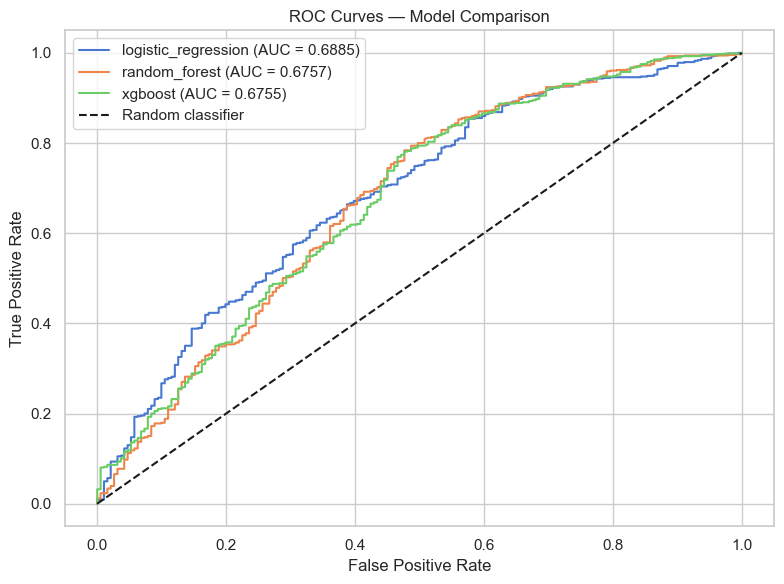

In [12]:
# ROC curves for all tuned models
plot_roc_curves(roc_data)

## 7. Threshold Optimisation

In [13]:
# Select the best model based on ROC-AUC from tuning results
best_model_name = max(results_tuned, key=lambda k: results_tuned[k]["roc_auc"])
best_model = tuned_models[best_model_name]
best_proba = predict_proba(best_model, X_val)

print(f"Best model: {best_model_name}")

# Find the threshold that maximises F1 for the Bad class
optimal_threshold = find_optimal_threshold(y_val, best_proba)

Best model: logistic_regression
Optimal threshold: 0.1089 (F1: 0.8796)


In [14]:
# Compare default threshold (0.5) vs optimal threshold
metrics_default = evaluate_model(y_val, best_proba, threshold=0.5)
metrics_optimal = evaluate_model(y_val, best_proba, threshold=optimal_threshold)

comparison = pd.DataFrame({
    "threshold=0.5": metrics_default,
    f"threshold={optimal_threshold:.3f}": metrics_optimal
}).T
comparison[["roc_auc", "f1_macro", "f1_bad", "recall_bad", "precision_bad"]]

,roc_auc,f1_macro,f1_bad,recall_bad,precision_bad
threshold=0.5,0.6885,0.6079,0.4217,0.5079,0.3606
threshold=0.109,0.6885,0.4699,0.0603,0.0314,0.7500


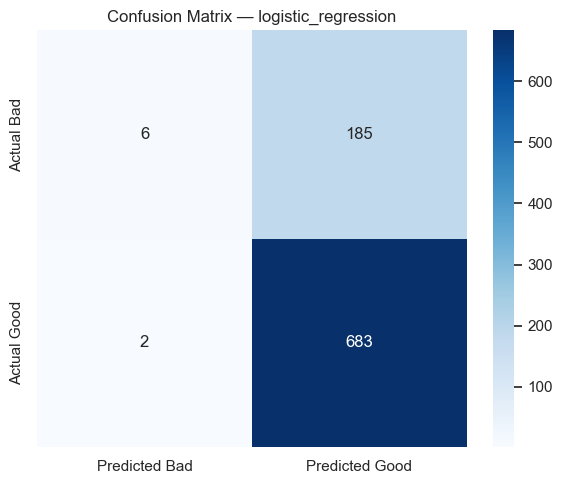

In [15]:
# Confusion matrix at optimal threshold
y_pred_optimal = (best_proba >= optimal_threshold).astype(int)
plot_confusion_matrix(y_val, y_pred_optimal, model_name=best_model_name)

## 8. Save Best Model

In [16]:
save_model(best_model, name=best_model_name)

Model saved to C:\Users\gwach\Documents\Data-Science-Stuff\ds_workplace\Portfolio\loan-default-risk\outputs\models\logistic_regression.joblib


## 9. SHAP Explainability

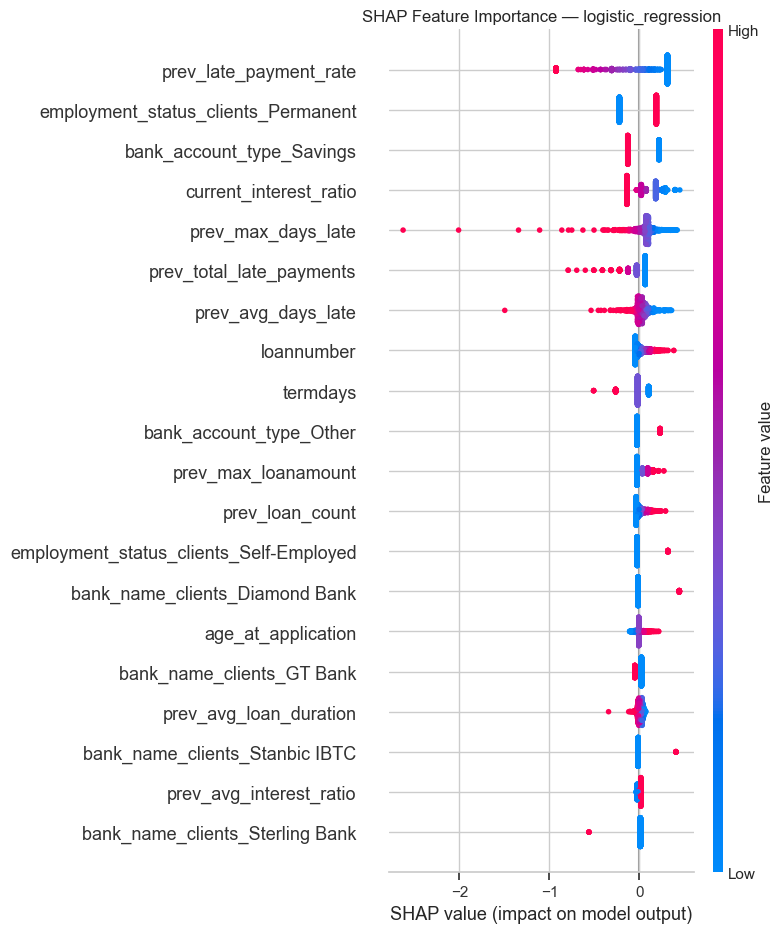

In [17]:
# SHAP explains which features push a prediction towards Good or Bad
# We use the validation set for explanation
plot_shap_summary(best_model, X_val, model_name=best_model_name)

## 10. Generate Zindi Submission

In [18]:
# Load and process test data
test_df = load_and_merge(split="test")

# Pass X_train.columns so test features align with what the model was trained on
X_test, _ = engineer_model_features(test_df, is_train=False, train_columns=X_train.columns.tolist())

# Predict using the best model and optimal threshold
test_proba = predict_proba(best_model, X_test)
test_pred = (test_proba >= optimal_threshold).astype(int)

print(f"Test predictions: {pd.Series(test_pred).value_counts().to_dict()}")

Test predictions: {1: 1433, 0: 17}


In [19]:
# Build submission file
submission = pd.DataFrame({
    "customerid": test_df["customerid"].values,
    "Good_Bad_flag": test_pred
})

submission_path = "../outputs/submissions/submission.csv"
submission.to_csv(submission_path, index=False)
print(f"Submission saved to {submission_path}")
submission.head()

Submission saved to ../outputs/submissions/submission.csv


,customerid,Good_Bad_flag
0,8a858899538ddb8e015390510b321f08,1
1,8a858959537a097401537a4e316e25f7,1
2,8a8589c253ace09b0153af6ba58f1f31,1
3,8a858e095aae82b7015aae86ca1e030b,1
4,8a858e225a28c713015a30db5c48383d,1


## 11. Summary of Results

*Fill in after running — key findings on which model performed best, what the optimal threshold was, which features SHAP identified as most important, and any honest limitations of the model.*